Imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, precision_score, recall_score, f1_score
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier

import joblib
import warnings
warnings.filterwarnings('ignore')

Load Data

In [2]:
train_df = pd.read_csv('train_motion_data.csv')
test_df = pd.read_csv('test_motion_data.csv')

print("Training Data Shape:", train_df.shape)
print("Testing Data Shape:", test_df.shape)
train_df.head()

Training Data Shape: (3644, 8)
Testing Data Shape: (3084, 8)


,AccX,AccY,AccZ,GyroX,GyroY,GyroZ,Class,Timestamp
0,0.000000,0.000000,0.000000,0.059407,-0.174707,0.101938,NORMAL,3581629
1,-1.624864,-1.082492,-0.204183,-0.028558,0.051313,0.135536,NORMAL,3581630
2,-0.594660,-0.122410,0.220502,-0.019395,-0.029322,0.087888,NORMAL,3581630
3,0.738478,-0.228456,0.667732,0.069791,-0.029932,0.054902,NORMAL,3581631
4,0.101741,0.777568,-0.066730,0.030696,-0.003665,0.054902,NORMAL,3581631


Exploratory Data Analysis

Missing values: 
 AccX         0
AccY         0
AccZ         0
GyroX        0
GyroY        0
GyroZ        0
Class        0
Timestamp    0
dtype: int64


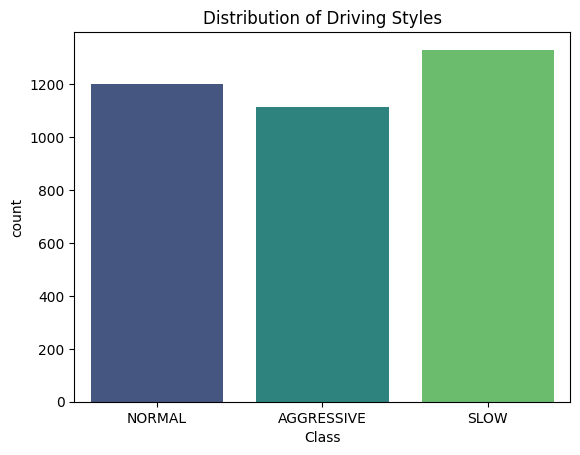

              AccX         AccY         AccZ        GyroX        GyroY  \
count  3644.000000  3644.000000  3644.000000  3644.000000  3644.000000   
mean      0.040467    -0.073418     0.008271     0.001593    -0.001273   
std       0.985653     0.903408     0.985061     0.066918     0.126205   
min      -4.636523    -4.699795    -7.143998    -0.751822    -1.587028   
25%      -0.550695    -0.592540    -0.558464    -0.028558    -0.053756   
50%       0.003931    -0.080833     0.002262     0.001985    -0.001833   
75%       0.595987     0.452401     0.556157     0.031918     0.051313   
max       4.985548     4.245151     5.171739     0.849255     1.679879   

             GyroZ     Timestamp  
count  3644.000000  3.644000e+03  
mean      0.007949  3.582707e+06  
std       0.115687  6.421479e+02  
min      -1.236468  3.581629e+06  
25%      -0.029398  3.582121e+06  
50%       0.002978  3.582702e+06  
75%       0.040852  3.583270e+06  
max       1.190500  3.583791e+06  


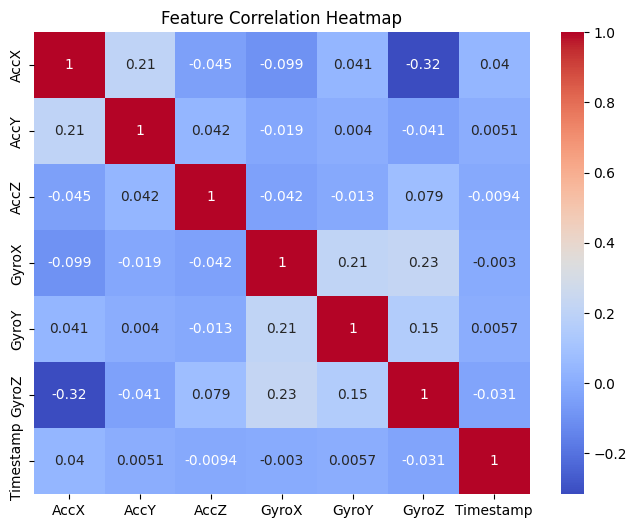

In [7]:
# Check for missing values
print("Missing values: \n", train_df.isnull().sum())

# Target Distribution
sns.countplot(x='Class', data=train_df, palette='viridis')
plt.title('Distribution of Driving Styles')
plt.show()

# Summary Statistics
print(train_df.describe())

# Correlation heatmap (use only numeric columns to avoid string -> float errors)
plt.figure(figsize=(8, 6))
numeric_df = train_df.select_dtypes(include=[np.number])
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm')
plt.title('Feature Correlation Heatmap')
plt.show()

Preprocessing

In [10]:
# Encode target labels
label_encoder = LabelEncoder()
train_df['Class_encoded'] = label_encoder.fit_transform(train_df['Class'])

# Feature and target split
X = train_df.drop(columns=['Class', 'Class_encoded', 'Timestamp'])
y = train_df['Class_encoded']

# Split for validation
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Standardize features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)

# Ensure test features match training features: drop Timestamp and Class if present,
# then reorder columns to match X (training feature order) before transforming.
test_features = test_df.drop(columns=['Timestamp', 'Class'], errors='ignore')
test_features = test_features[X.columns]
test_scaled = scaler.transform(test_features)

print("Data preprocessing complete.")

Data preprocessing complete.


Model Training and Evaluation

In [1]:
def evaluate_model(model, X_train, y_train, X_val, y_val):
    model.fit(X_train, y_train)
    y_pred = model.predict(X_val)
    
    print("\nClassification Report:\n", classification_report(y_val, y_pred))
    print("Accuracy:", accuracy_score(y_val, y_pred))
    print("Precision:", precision_score(y_val, y_pred, average='weighted'))
    print("Recall:", recall_score(y_val, y_pred, average='weighted'))
    print("F1 Score:", f1_score(y_val, y_pred, average='weighted'))
    
    cm = confusion_matrix(y_val, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=label_encoder.classes_, yticklabels=label_encoder.classes_)
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.title(f'Confusion Matrix - {model.__class__.__name__}')
    plt.show()

Try Baseline Models

In [ ]:
# Logistic Regression
print("Evaluating Logistic Regression...")
evaluate_model(LogisticRegression(max_iter=500), X_train_scaled, y_train, X_val_scaled, y_val)

# Random Forest
print("Evaluating Random Forest...")
evaluate_model(RandomForestClassifier(n_estimators=100, random_state=42), X_train_scaled, y_train, X_val_scaled, y_val)

# Support Vector Machine
print("Evaluating Support Vector Machine...")
evaluate_model(SVC(kernel='rbf', C=1, gamma='scale'), X_train_scaled, y_train, X_val_scaled, y_val)

# XGBoost
print("Evaluating XGBoost...")
evaluate_model(XGBClassifier(use_label_encoder=False, eval_metric='mlogloss', random_state=42), X_train_scaled, y_train, X_val_scaled, y_val)

Hyperparameter Tuning